In [1]:
pip install river matplotlib pandas

In [2]:
from river import datasets
import pandas as pd

# Load ELEC2 stream
dataset = datasets.Elec2()

# Convert stream to DataFrame for inspection
rows = []

for x, y in dataset:
    row = x.copy()
    row["target"] = y
    rows.append(row)

df = pd.DataFrame(rows)

# Show basic dataset information
print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head(10))

print("\nData types:")
display(df.dtypes)

print("\nColumn names:")
print(df.columns.tolist())

print("\nTarget distribution:")
display(df["target"].value_counts())

print("\nTarget distribution percentage:")
display(df["target"].value_counts(normalize=True) * 100)

print("\nMissing values:")
display(df.isnull().sum())

Uncompressing into /root/river_data/Elec2
Dataset shape:
(45312, 9)

First 5 rows:


,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,target
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,True
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,True
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,True
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,True
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,False
5,0.0,2,0.106383,0.041161,0.207528,0.003467,0.422915,0.414912,False
6,0.0,2,0.127660,0.041161,0.171824,0.003467,0.422915,0.414912,False
7,0.0,2,0.148936,0.041161,0.152782,0.003467,0.422915,0.414912,False
8,0.0,2,0.170213,0.041161,0.134930,0.003467,0.422915,0.414912,False
9,0.0,2,0.191489,0.041161,0.140583,0.003467,0.422915,0.414912,False



Data types:


,0
date,float64
day,int64
period,float64
nswprice,float64
nswdemand,float64
vicprice,float64
vicdemand,float64
transfer,float64
target,bool



Column names:
['date', 'day', 'period', 'nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer', 'target']

Target distribution:


,count
target,
False,26075
True,19237



Target distribution percentage:


,proportion
target,
False,57.545463
True,42.454537



Missing values:


,0
date,0
day,0
period,0
nswprice,0
nswdemand,0
vicprice,0
vicdemand,0
transfer,0
target,0


The dataset contains 45,312 observations and multiple input features representing electricity market conditions. The target variable is binary and indicates whether the electricity price moves up or down. The dataset was inspected for feature types, class distribution, and missing values before model development. Since the dataset is provided by River in a stream-ready format, no extensive preprocessing was required.

Total samples processed: 45312
Final online accuracy: 0.8454
Total drifts detected: 43
Drift points: [1505, 3073, 4449, 9313, 9985, 11809, 14145, 16289, 16737, 17185, 18881, 19777, 20641, 21313, 22945, 24513, 25889, 26209, 27233, 27553]


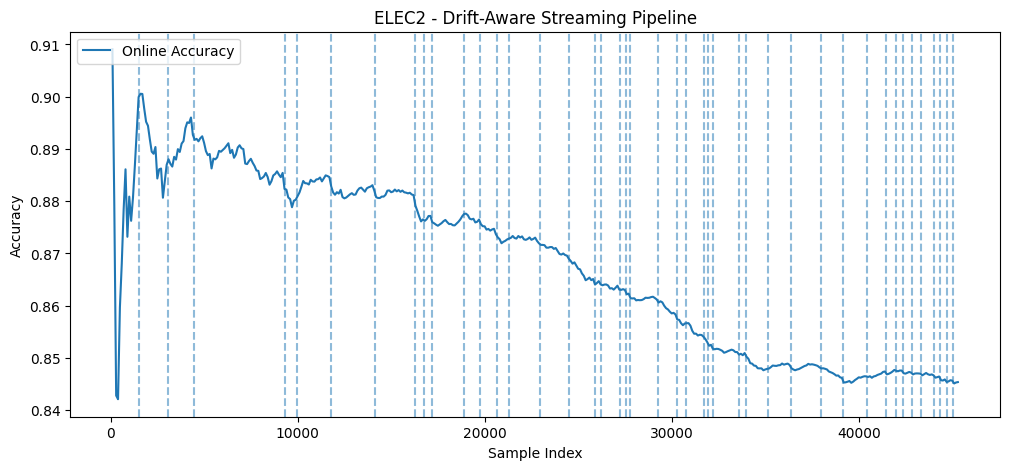

In [3]:
from river import datasets, tree, drift, metrics
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD THE STREAMING DATASET
# -----------------------------
dataset = datasets.Elec2()

# -----------------------------
# 2. CHOOSE THE ONLINE MODEL
# -----------------------------
# Hoeffding Tree is a common streaming classifier
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

model = make_model()

# -----------------------------
# 3. DRIFT DETECTOR
# -----------------------------
# ADWIN monitors a 1D stream; here we send model errors (0 correct, 1 wrong)
detector = drift.ADWIN(delta=0.002)

# -----------------------------
# 4. METRICS AND LOGGING
# -----------------------------
metric = metrics.Accuracy()

n_samples = 0
drift_points = []
accuracy_history = []
sample_index_history = []

# Optional: keep counts for reporting
n_drifts = 0

# -----------------------------
# 5. STREAMING LOOP
# -----------------------------
for x, y in dataset:
    n_samples += 1

    # Predict before learning (important in streaming evaluation)
    y_pred = model.predict_one(x)

    # If model has started learning, evaluate it
    if y_pred is not None:
        metric.update(y, y_pred)

        # error = 0 if correct, 1 if wrong
        error = 0 if y_pred == y else 1

        # update ADWIN with the error stream
        detector.update(error)

        # if drift is detected, reset the model automatically
        if detector.drift_detected:
            n_drifts += 1
            drift_points.append(n_samples)

            # reset model
            model = make_model()

            # reset detector too, so it can start monitoring fresh
            detector = drift.ADWIN(delta=0.002)

    # Learn from current sample
    model.learn_one(x, y)

    # Store history every 100 samples for plotting
    if n_samples % 100 == 0:
        accuracy_history.append(metric.get())
        sample_index_history.append(n_samples)

# -----------------------------
# 6. FINAL RESULTS
# -----------------------------
print(f"Total samples processed: {n_samples}")
print(f"Final online accuracy: {metric.get():.4f}")
print(f"Total drifts detected: {n_drifts}")
print(f"Drift points: {drift_points[:20]}")  # show first 20 only

# -----------------------------
# 7. PLOT ACCURACY OVER TIME
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(sample_index_history, accuracy_history, label="Online Accuracy")

for dp in drift_points:
    plt.axvline(dp, linestyle="--", alpha=0.5)

plt.xlabel("Sample Index")
plt.ylabel("Accuracy")
plt.title("ELEC2 - Drift-Aware Streaming Pipeline")
plt.legend()
plt.show()

Total samples processed: 45312
Final online accuracy: 0.8345
Total drifts detected: 56
Buffer size used: 200
Drift points: [1505, 2145, 2625, 4417, 5089, 5921, 7201, 9313, 10241, 11553, 12641, 12833, 14049, 16161, 17025, 18817, 19073, 19265, 19777, 20577]


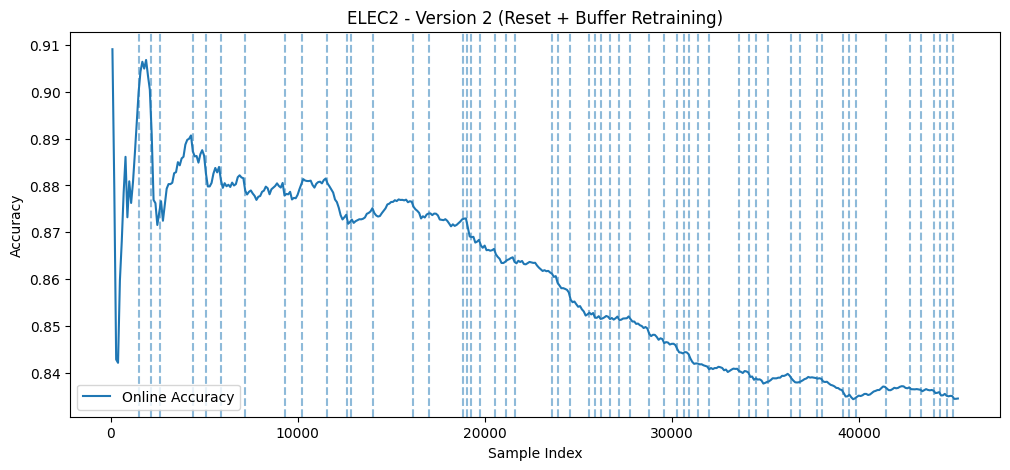

In [4]:
from river import datasets, tree, drift, metrics
from collections import deque
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
dataset = datasets.Elec2()

# -----------------------------
# 2. MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

model = make_model()

# -----------------------------
# 3. DRIFT DETECTOR
# -----------------------------
detector = drift.ADWIN(delta=0.002)

# -----------------------------
# 4. METRICS AND LOGGING
# -----------------------------
metric = metrics.Accuracy()

n_samples = 0
n_drifts = 0
drift_points = []

accuracy_history = []
sample_index_history = []

# -----------------------------
# 5. BUFFER FOR RECENT SAMPLES
# -----------------------------
# stores the most recent N samples
BUFFER_SIZE = 200
recent_buffer = deque(maxlen=BUFFER_SIZE)

# -----------------------------
# 6. STREAMING LOOP
# -----------------------------
for x, y in dataset:
    n_samples += 1

    # Predict before learning
    y_pred = model.predict_one(x)

    # Evaluate only if prediction exists
    if y_pred is not None:
        metric.update(y, y_pred)

        # Convert prediction result into error stream
        error = 0 if y_pred == y else 1

        # Update drift detector
        detector.update(error)

        # If drift is detected, reset + retrain from recent buffer
        if detector.drift_detected:
            n_drifts += 1
            drift_points.append(n_samples)

            # Create fresh model
            model = make_model()

            # Retrain new model on recent buffered samples
            for bx, by in recent_buffer:
                model.learn_one(bx, by)

            # Reset detector after drift
            detector = drift.ADWIN(delta=0.002)

    # Learn current sample
    model.learn_one(x, y)

    # Add current sample to recent buffer
    recent_buffer.append((x, y))

    # Store accuracy history every 100 samples
    if n_samples % 100 == 0:
        accuracy_history.append(metric.get())
        sample_index_history.append(n_samples)

# -----------------------------
# 7. FINAL RESULTS
# -----------------------------
print(f"Total samples processed: {n_samples}")
print(f"Final online accuracy: {metric.get():.4f}")
print(f"Total drifts detected: {n_drifts}")
print(f"Buffer size used: {BUFFER_SIZE}")
print(f"Drift points: {drift_points[:20]}")  # first 20 only

# -----------------------------
# 8. PLOT
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(sample_index_history, accuracy_history, label="Online Accuracy")

for dp in drift_points:
    plt.axvline(dp, linestyle="--", alpha=0.5)

plt.xlabel("Sample Index")
plt.ylabel("Accuracy")
plt.title("ELEC2 - Version 2 (Reset + Buffer Retraining)")
plt.legend()
plt.show()

Running experiment: ADWIN delta=0.005, buffer_size=100
Running experiment: ADWIN delta=0.005, buffer_size=250
Running experiment: ADWIN delta=0.005, buffer_size=500
Running experiment: ADWIN delta=0.005, buffer_size=1000
Running experiment: ADWIN delta=0.002, buffer_size=100
Running experiment: ADWIN delta=0.002, buffer_size=250
Running experiment: ADWIN delta=0.002, buffer_size=500
Running experiment: ADWIN delta=0.002, buffer_size=1000
Running experiment: ADWIN delta=0.001, buffer_size=100
Running experiment: ADWIN delta=0.001, buffer_size=250
Running experiment: ADWIN delta=0.001, buffer_size=500
Running experiment: ADWIN delta=0.001, buffer_size=1000
Running experiment: ADWIN delta=0.0005, buffer_size=100
Running experiment: ADWIN delta=0.0005, buffer_size=250
Running experiment: ADWIN delta=0.0005, buffer_size=500
Running experiment: ADWIN delta=0.0005, buffer_size=1000

Experiment Results:


,ADWIN Delta,Buffer Size,Final Accuracy,Total Drifts
0,0.0050,1000,0.8358,58
1,0.0010,100,0.8337,37
2,0.0020,250,0.8334,45
3,0.0010,250,0.8319,40
4,0.0020,500,0.8313,46
5,0.0020,100,0.8312,46
6,0.0005,100,0.8311,36
7,0.0050,100,0.8310,59
8,0.0050,500,0.8288,57
9,0.0050,250,0.8285,65



Best Configuration:
ADWIN Delta: 0.005
Buffer Size: 1000.0
Final Accuracy: 0.8358
Total Drifts: 58.0


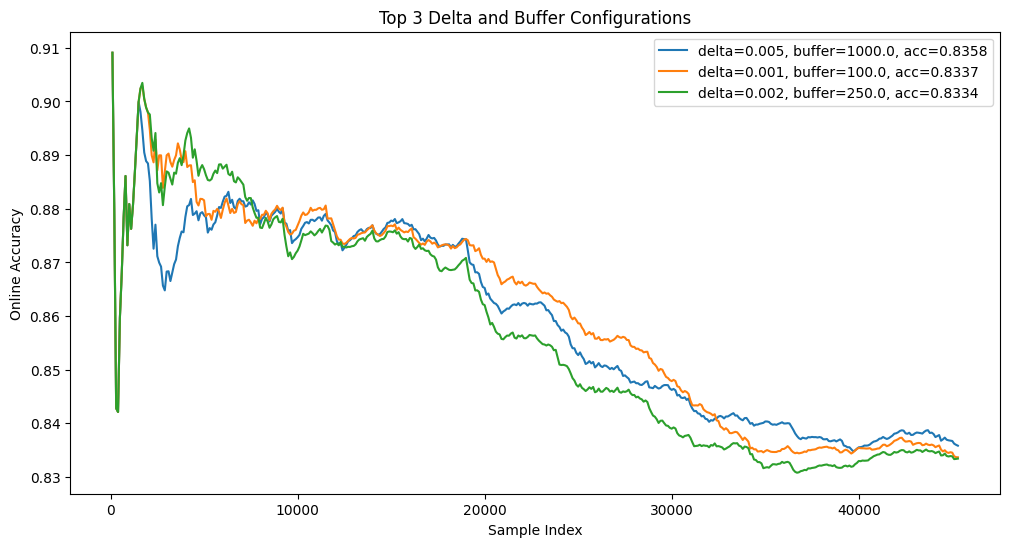

In [5]:
from river import datasets, tree, drift, metrics
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# -----------------------------
# 2. EXPERIMENT FUNCTION
# -----------------------------
def run_experiment(adwin_delta, buffer_size):
    dataset = datasets.Elec2()

    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta)
    metric = metrics.Accuracy()

    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0
    drift_points = []

    accuracy_history = []
    sample_history = []

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

            error = 0 if y_pred == y else 1
            detector.update(error)

            if detector.drift_detected:
                n_drifts += 1
                drift_points.append(n_samples)

                # Reset model
                model = make_model()

                # Retrain on recent buffer
                for bx, by in recent_buffer:
                    model.learn_one(bx, by)

                # Reset detector
                detector = drift.ADWIN(delta=adwin_delta)

        # Learn current sample
        model.learn_one(x, y)

        # Store sample in buffer
        recent_buffer.append((x, y))

        # Store accuracy every 100 samples
        if n_samples % 100 == 0:
            accuracy_history.append(metric.get())
            sample_history.append(n_samples)

    return {
        "adwin_delta": adwin_delta,
        "buffer_size": buffer_size,
        "final_accuracy": metric.get(),
        "total_drifts": n_drifts,
        "drift_points": drift_points,
        "accuracy_history": accuracy_history,
        "sample_history": sample_history
    }

# -----------------------------
# 3. VALUES TO TEST
# -----------------------------
adwin_deltas = [0.005, 0.002, 0.001, 0.0005]
buffer_sizes = [100, 250, 500, 1000]

# -----------------------------
# 4. RUN GRID SEARCH
# -----------------------------
results = []

for d in adwin_deltas:
    for b in buffer_sizes:
        print(f"Running experiment: ADWIN delta={d}, buffer_size={b}")

        result = run_experiment(
            adwin_delta=d,
            buffer_size=b
        )

        results.append(result)

# -----------------------------
# 5. CREATE RESULTS TABLE
# -----------------------------
summary_rows = []

for r in results:
    summary_rows.append({
        "ADWIN Delta": r["adwin_delta"],
        "Buffer Size": r["buffer_size"],
        "Final Accuracy": round(r["final_accuracy"], 4),
        "Total Drifts": r["total_drifts"]
    })

results_df = pd.DataFrame(summary_rows)

# Sort by highest accuracy first
results_df = results_df.sort_values(
    by="Final Accuracy",
    ascending=False
).reset_index(drop=True)

print("\nExperiment Results:")
display(results_df)

# -----------------------------
# 6. SHOW BEST CONFIGURATION
# -----------------------------
best_result = results_df.iloc[0]

print("\nBest Configuration:")
print(f"ADWIN Delta: {best_result['ADWIN Delta']}")
print(f"Buffer Size: {best_result['Buffer Size']}")
print(f"Final Accuracy: {best_result['Final Accuracy']}")
print(f"Total Drifts: {best_result['Total Drifts']}")

# -----------------------------
# 7. PLOT TOP 3 CONFIGURATIONS
# -----------------------------
top_3 = results_df.head(3)

plt.figure(figsize=(12, 6))

for _, row in top_3.iterrows():
    d = row["ADWIN Delta"]
    b = row["Buffer Size"]

    matching_result = next(
        r for r in results
        if r["adwin_delta"] == d and r["buffer_size"] == b
    )

    label = f"delta={d}, buffer={b}, acc={row['Final Accuracy']}"

    plt.plot(
        matching_result["sample_history"],
        matching_result["accuracy_history"],
        label=label
    )

plt.xlabel("Sample Index")
plt.ylabel("Online Accuracy")
plt.title("Top 3 Delta and Buffer Configurations")
plt.legend()
plt.show()

In [6]:
from river import datasets, tree, drift, metrics
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# -----------------------------
# 2. RUN ONE EXPERIMENT
# -----------------------------
def run_experiment(adwin_delta, buffer_size):
    dataset = datasets.Elec2()

    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta)
    metric = metrics.Accuracy()

    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0

    accuracy_history = []
    sample_history = []

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

            # Error stream: 0 = correct, 1 = wrong
            error = 0 if y_pred == y else 1
            detector.update(error)

            if detector.drift_detected:
                n_drifts += 1

                # Reset model
                model = make_model()

                # Retrain on recent buffer
                for bx, by in recent_buffer:
                    model.learn_one(bx, by)

                # Reset ADWIN
                detector = drift.ADWIN(delta=adwin_delta)

        # Learn current sample
        model.learn_one(x, y)

        # Store recent sample
        recent_buffer.append((x, y))

        # Store accuracy every 100 samples
        if n_samples % 100 == 0:
            accuracy_history.append(metric.get())
            sample_history.append(n_samples)

    return {
        "ADWIN Delta": adwin_delta,
        "Buffer Size": buffer_size,
        "Final Accuracy": metric.get(),
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history
    }

# -----------------------------
# 3. HYPERPARAMETERS TO TEST
# -----------------------------
adwin_deltas = [0.005, 0.002, 0.001, 0.0005]
buffer_sizes = [100, 250, 500, 1000]

# -----------------------------
# 4. RUN ALL EXPERIMENTS
# -----------------------------
results = []

for d in adwin_deltas:
    for b in buffer_sizes:
        print(f"Running: ADWIN delta={d}, buffer_size={b}")
        result = run_experiment(d, b)
        results.append(result)

# -----------------------------
# 5. CREATE RESULTS TABLE
# -----------------------------
summary = []

for r in results:
    summary.append({
        "ADWIN Delta": r["ADWIN Delta"],
        "Buffer Size": r["Buffer Size"],
        "Final Accuracy": round(r["Final Accuracy"], 4),
        "Total Drifts": r["Total Drifts"]
    })

results_df = pd.DataFrame(summary)

# -----------------------------
# 6. BALANCED SELECTION SCORE
# -----------------------------
# We reward accuracy and penalize too many drift detections.
# This avoids choosing a configuration only because of tiny accuracy gain.
results_df["Balanced Score"] = (
    results_df["Final Accuracy"] - (0.00005 * results_df["Total Drifts"])
)

results_df = results_df.sort_values(
    by="Balanced Score",
    ascending=False
).reset_index(drop=True)

print("\nFinal Comparison Table:")
display(results_df)

# -----------------------------
# 7. BEST CONFIGURATION
# -----------------------------
best = results_df.iloc[0]

print("\nBest Balanced Configuration:")
print(f"ADWIN Delta: {best['ADWIN Delta']}")
print(f"Buffer Size: {best['Buffer Size']}")
print(f"Final Accuracy: {best['Final Accuracy']}")
print(f"Total Drifts: {best['Total Drifts']}")
print(f"Balanced Score: {best['Balanced Score']:.4f}")

# -----------------------------
# 8. PLOT BEST CONFIGURATION
# -----------------------------
best_delta = best["ADWIN Delta"]
best_buffer = best["Buffer Size"]

best_result = next(
    r for r in results
    if r["ADWIN Delta"] == best_delta and r["Buffer Size"] == best_buffer
)

plt.figure(figsize=(12, 5))
plt.plot(
    best_result["Sample History"],
    best_result["Accuracy History"],
    label=f"Best: delta={best_delta}, buffer={best_buffer}"
)

plt.xlabel("Sample Index")
plt.ylabel("Online Accuracy")
plt.title("Best Balanced Drift-Aware Configuration")
plt.legend()
plt.show()

Running: ADWIN delta=0.005, buffer_size=100
Running: ADWIN delta=0.005, buffer_size=250
Running: ADWIN delta=0.005, buffer_size=500
Running: ADWIN delta=0.005, buffer_size=1000
Running: ADWIN delta=0.002, buffer_size=100
Running: ADWIN delta=0.002, buffer_size=250
Running: ADWIN delta=0.002, buffer_size=500


KeyboardInterrupt: 

In [ ]:
from river import datasets, tree, drift, metrics
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# -----------------------------
# 2. RUN ONE EXPERIMENT
# -----------------------------
def run_experiment(adwin_delta, buffer_size):
    dataset = datasets.Elec2()

    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta)
    metric = metrics.Accuracy()

    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0

    accuracy_history = []
    sample_history = []

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

            # Error stream: 0 = correct, 1 = wrong
            error = 0 if y_pred == y else 1
            detector.update(error)

            if detector.drift_detected:
                n_drifts += 1

                # Reset model
                model = make_model()

                # Retrain on recent buffer
                for bx, by in recent_buffer:
                    model.learn_one(bx, by)

                # Reset ADWIN
                detector = drift.ADWIN(delta=adwin_delta)

        # Learn current sample
        model.learn_one(x, y)

        # Store recent sample
        recent_buffer.append((x, y))

        # Store accuracy every 100 samples
        if n_samples % 100 == 0:
            accuracy_history.append(metric.get())
            sample_history.append(n_samples)

    return {
        "ADWIN Delta": adwin_delta,
        "Buffer Size": buffer_size,
        "Final Accuracy": metric.get(),
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history
    }

# -----------------------------
# 3. HYPERPARAMETERS TO TEST
# -----------------------------
adwin_deltas = [0.005, 0.002, 0.001, 0.0005]
buffer_sizes = [100, 250, 500, 1000]

# -----------------------------
# 4. RUN ALL EXPERIMENTS
# -----------------------------
results = []

for d in adwin_deltas:
    for b in buffer_sizes:
        print(f"Running: ADWIN delta={d}, buffer_size={b}")
        result = run_experiment(d, b)
        results.append(result)

# -----------------------------
# 5. CREATE RESULTS TABLE
# -----------------------------
summary = []

for r in results:
    summary.append({
        "ADWIN Delta": r["ADWIN Delta"],
        "Buffer Size": r["Buffer Size"],
        "Final Accuracy": round(r["Final Accuracy"], 4),
        "Total Drifts": r["Total Drifts"]
    })

results_df = pd.DataFrame(summary)

# -----------------------------
# 6. BALANCED SELECTION SCORE
# -----------------------------
# We reward accuracy and penalize too many drift detections.
# This avoids choosing a configuration only because of tiny accuracy gain.
results_df["Balanced Score"] = (
    results_df["Final Accuracy"] - (0.0002 * results_df["Total Drifts"])
)

results_df = results_df.sort_values(
    by="Balanced Score",
    ascending=False
).reset_index(drop=True)

print("\nFinal Comparison Table:")
display(results_df)

# -----------------------------
# 7. BEST CONFIGURATION
# -----------------------------
best = results_df.iloc[0]

print("\nBest Balanced Configuration:")
print(f"ADWIN Delta: {best['ADWIN Delta']}")
print(f"Buffer Size: {best['Buffer Size']}")
print(f"Final Accuracy: {best['Final Accuracy']}")
print(f"Total Drifts: {best['Total Drifts']}")
print(f"Balanced Score: {best['Balanced Score']:.4f}")

# -----------------------------
# 8. PLOT BEST CONFIGURATION
# -----------------------------
best_delta = best["ADWIN Delta"]
best_buffer = best["Buffer Size"]

best_result = next(
    r for r in results
    if r["ADWIN Delta"] == best_delta and r["Buffer Size"] == best_buffer
)

plt.figure(figsize=(12, 5))
plt.plot(
    best_result["Sample History"],
    best_result["Accuracy History"],
    label=f"Best: delta={best_delta}, buffer={best_buffer}"
)

plt.xlabel("Sample Index")
plt.ylabel("Online Accuracy")
plt.title("Best Balanced Drift-Aware Configuration")
plt.legend()
plt.show()

# Baseline model

In [2]:
from river import datasets, tree, drift, metrics
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# -----------------------------
# BASELINE MODEL
# No ADWIN, no drift detection, no adaptation
# -----------------------------
def run_baseline():
    dataset = datasets.Elec2()
    model = make_model()
    metric = metrics.Accuracy()

    n_samples = 0
    sample_history = []
    accuracy_history = []

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

        # Learn continuously
        model.learn_one(x, y)

        if n_samples % 100 == 0:
            sample_history.append(n_samples)
            accuracy_history.append(metric.get())

    return {
        "Method": "Baseline: Hoeffding Tree only",
        "Final Accuracy": round(metric.get(), 4),
        "Total Drifts": 0,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history,
        "Drift Points": []
    }


Final Comparison Table:


,Method,ADWIN Delta,Buffer Size,Final Accuracy,Total Drifts,Adaptation
0,Baseline: Hoeffding Tree only,N/A,N/A,0.8132,0,None
1,Adaptive: ADWIN + Buffer Retraining,0.001,100,0.8337,37,Reset + recent buffer retraining


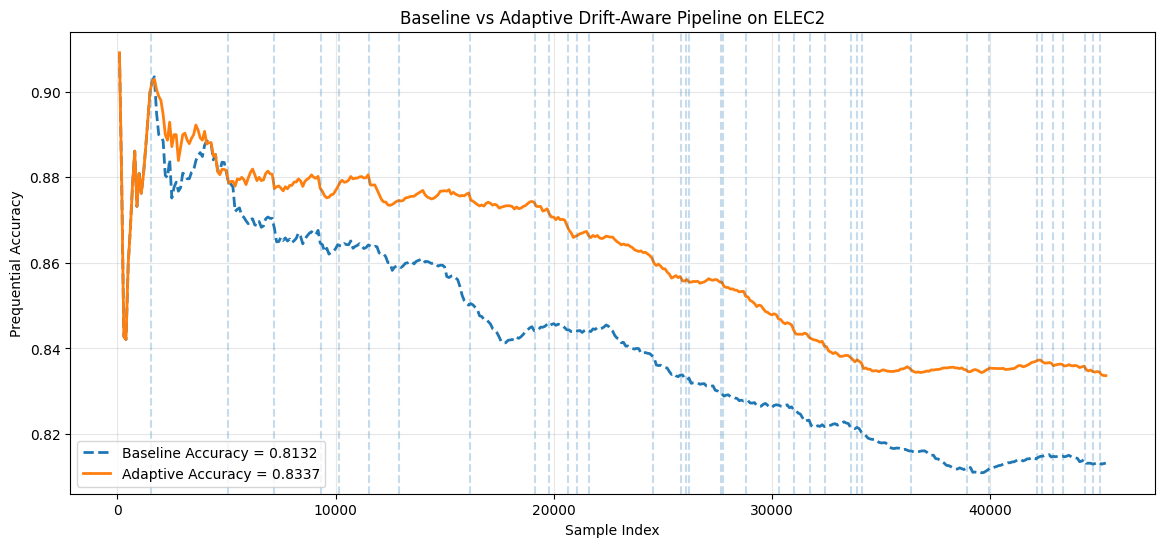


Final Results
Baseline Accuracy : 0.8132
Adaptive Accuracy : 0.8337
Drifts Detected   : 37
ADWIN Delta Used  : 0.001
Buffer Size Used  : 100


In [3]:
# -----------------------------
# FINAL ADAPTIVE PIPELINE
# ADWIN + reset + buffer retraining
# -----------------------------
def run_adaptive_pipeline(adwin_delta=0.001, buffer_size=100):
    dataset = datasets.Elec2()
    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta)
    metric = metrics.Accuracy()

    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0
    drift_points = []

    sample_history = []
    accuracy_history = []

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

            # ADWIN monitors prediction error
            error = 0 if y_pred == y else 1
            detector.update(error)

            # If drift is detected, adapt automatically
            if detector.drift_detected:
                n_drifts += 1
                drift_points.append(n_samples)

                # Reset model
                model = make_model()

                # Retrain on recent buffer
                for bx, by in recent_buffer:
                    model.learn_one(bx, by)

                # Reset detector after adaptation
                detector = drift.ADWIN(delta=adwin_delta)

        # Learn current sample
        model.learn_one(x, y)

        # Store recent sample for future retraining
        recent_buffer.append((x, y))

        if n_samples % 100 == 0:
            sample_history.append(n_samples)
            accuracy_history.append(metric.get())

    return {
        "Method": "Adaptive: ADWIN + Buffer Retraining",
        "ADWIN Delta": adwin_delta,
        "Buffer Size": buffer_size,
        "Final Accuracy": round(metric.get(), 4),
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history,
        "Drift Points": drift_points
    }

# -----------------------------
# RUN BOTH MODELS
# -----------------------------
baseline = run_baseline()
adaptive = run_adaptive_pipeline(adwin_delta=0.001, buffer_size=100)

# -----------------------------
# RESULTS TABLE
# -----------------------------
results_df = pd.DataFrame([
    {
        "Method": baseline["Method"],
        "ADWIN Delta": "N/A",
        "Buffer Size": "N/A",
        "Final Accuracy": baseline["Final Accuracy"],
        "Total Drifts": baseline["Total Drifts"],
        "Adaptation": "None"
    },
    {
        "Method": adaptive["Method"],
        "ADWIN Delta": adaptive["ADWIN Delta"],
        "Buffer Size": adaptive["Buffer Size"],
        "Final Accuracy": adaptive["Final Accuracy"],
        "Total Drifts": adaptive["Total Drifts"],
        "Adaptation": "Reset + recent buffer retraining"
    }
])

print("Final Comparison Table:")
display(results_df)

# -----------------------------
# PLOT COMPARISON
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    baseline["Sample History"],
    baseline["Accuracy History"],
    label=f"Baseline Accuracy = {baseline['Final Accuracy']}",
    linestyle="--",
    linewidth=2
)

plt.plot(
    adaptive["Sample History"],
    adaptive["Accuracy History"],
    label=f"Adaptive Accuracy = {adaptive['Final Accuracy']}",
    linewidth=2
)

for dp in adaptive["Drift Points"]:
    plt.axvline(dp, linestyle="--", alpha=0.25)

plt.xlabel("Sample Index")
plt.ylabel("Prequential Accuracy")
plt.title("Baseline vs Adaptive Drift-Aware Pipeline on ELEC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# FINAL PRINT SUMMARY
# -----------------------------
print("\nFinal Results")
print(f"Baseline Accuracy : {baseline['Final Accuracy']}")
print(f"Adaptive Accuracy : {adaptive['Final Accuracy']}")
print(f"Drifts Detected   : {adaptive['Total Drifts']}")
print(f"ADWIN Delta Used  : {adaptive['ADWIN Delta']}")
print(f"Buffer Size Used  : {adaptive['Buffer Size']}")

# adding confusion metrics, F1 score, Recall, precision and ROLLING ACCURACY

Final Evaluation Metrics:


,Method,ADWIN Delta,Buffer Size,Accuracy,Macro Precision,Macro Recall,Macro F1,Total Drifts,Adaptation
0,Baseline: Hoeffding Tree only,N/A,N/A,0.8132,0.8088,0.8093,0.8091,0,None
1,Adaptive: ADWIN + Buffer Retraining,0.001,100,0.8337,0.8320,0.8258,0.8283,37,Reset + recent buffer retraining



Baseline Confusion Matrix:


Predicted,False,True
Actual,,
False,21781,4294
True,4168,15068



Adaptive Pipeline Confusion Matrix:


Predicted,False,True
Actual,,
False,22891,3184
True,4353,14883


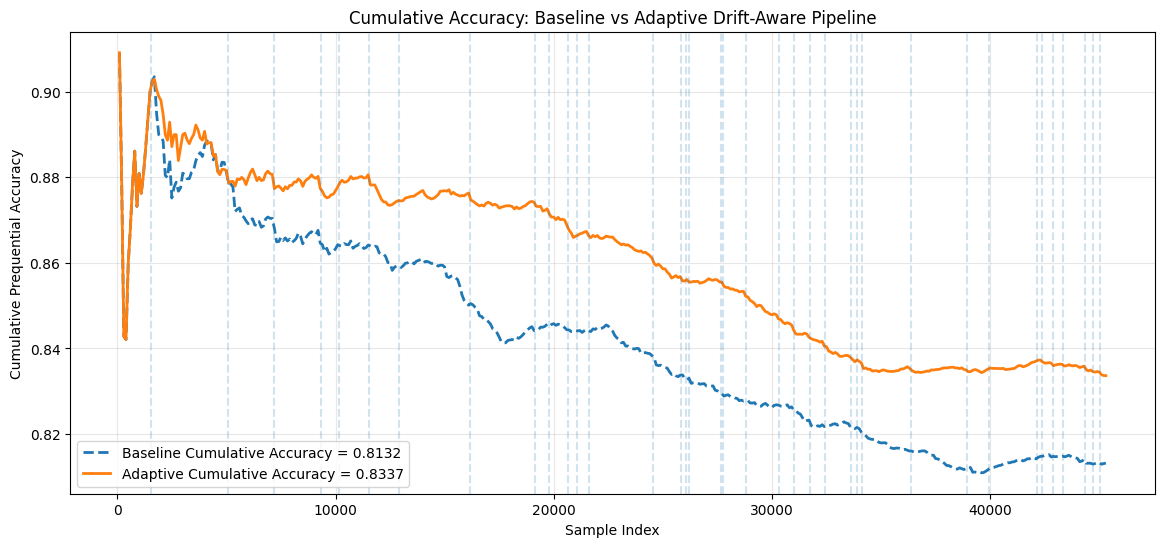

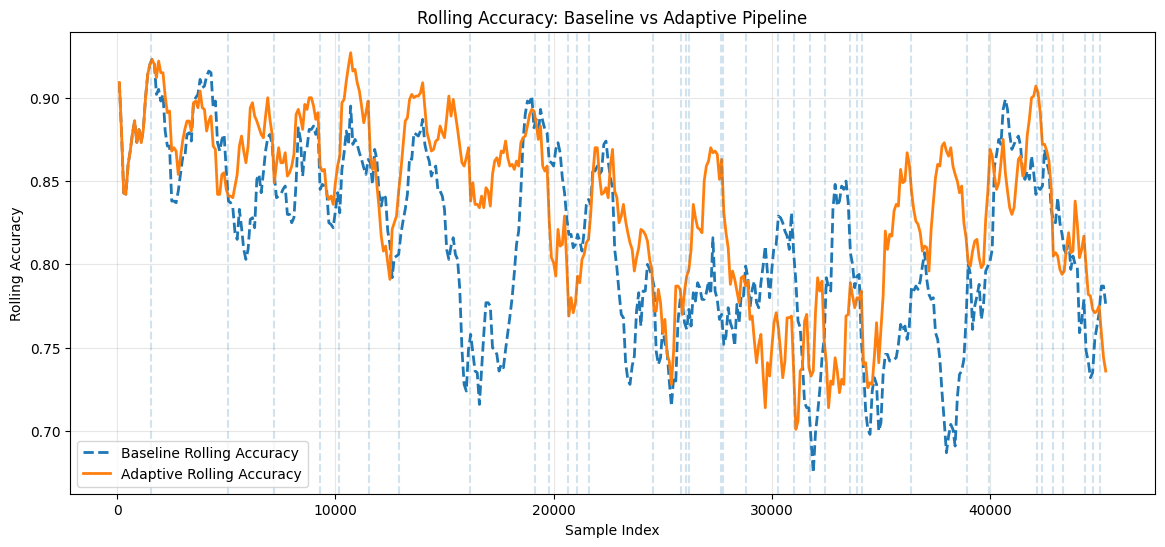


Final Results Summary
Baseline Accuracy       : 0.8132
Baseline Macro F1       : 0.8091
Adaptive Accuracy       : 0.8337
Adaptive Macro F1       : 0.8283
Drifts Detected         : 37
ADWIN Delta Used        : 0.001
Buffer Size Used        : 100


In [4]:
from river import datasets, tree, drift
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# -----------------------------
# MODEL FACTORY
# -----------------------------
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# -----------------------------
# HELPER FUNCTION FOR METRICS
# -----------------------------
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro Recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4)
    }

# -----------------------------
# BASELINE MODEL
# No ADWIN, no drift detection, no adaptation
# -----------------------------
def run_baseline(rolling_window=1000):
    dataset = datasets.Elec2()
    model = make_model()

    n_samples = 0

    sample_history = []
    cumulative_accuracy_history = []
    rolling_accuracy_history = []

    y_true_list = []
    y_pred_list = []

    rolling_correct = deque(maxlen=rolling_window)

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            y_true_list.append(y)
            y_pred_list.append(y_pred)

            correct = 1 if y_pred == y else 0
            rolling_correct.append(correct)

        # Learn continuously
        model.learn_one(x, y)

        if n_samples % 100 == 0 and len(y_true_list) > 0:
            cumulative_acc = accuracy_score(y_true_list, y_pred_list)
            rolling_acc = sum(rolling_correct) / len(rolling_correct)

            sample_history.append(n_samples)
            cumulative_accuracy_history.append(cumulative_acc)
            rolling_accuracy_history.append(rolling_acc)

    final_metrics = calculate_metrics(y_true_list, y_pred_list)

    confusion_matrix = pd.crosstab(
        pd.Series(y_true_list, name="Actual"),
        pd.Series(y_pred_list, name="Predicted")
    )

    return {
        "Method": "Baseline: Hoeffding Tree only",
        "Final Metrics": final_metrics,
        "Total Drifts": 0,
        "Sample History": sample_history,
        "Cumulative Accuracy History": cumulative_accuracy_history,
        "Rolling Accuracy History": rolling_accuracy_history,
        "Drift Points": [],
        "Confusion Matrix": confusion_matrix
    }

# -----------------------------
# FINAL ADAPTIVE PIPELINE
# ADWIN + reset + buffer retraining
# -----------------------------
def run_adaptive_pipeline(adwin_delta=0.001, buffer_size=100, rolling_window=1000):
    dataset = datasets.Elec2()
    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta)

    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0
    drift_points = []

    sample_history = []
    cumulative_accuracy_history = []
    rolling_accuracy_history = []

    y_true_list = []
    y_pred_list = []

    rolling_correct = deque(maxlen=rolling_window)

    for x, y in dataset:
        n_samples += 1

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is not None:
            y_true_list.append(y)
            y_pred_list.append(y_pred)

            correct = 1 if y_pred == y else 0
            rolling_correct.append(correct)

            # ADWIN monitors prediction error
            error = 0 if y_pred == y else 1
            detector.update(error)

            # If drift is detected, adapt automatically
            if detector.drift_detected:
                n_drifts += 1
                drift_points.append(n_samples)

                # Reset model
                model = make_model()

                # Retrain using recent buffer
                for bx, by in recent_buffer:
                    model.learn_one(bx, by)

                # Reset detector after adaptation
                detector = drift.ADWIN(delta=adwin_delta)

        # Learn current sample
        model.learn_one(x, y)

        # Store recent sample for future adaptation
        recent_buffer.append((x, y))

        if n_samples % 100 == 0 and len(y_true_list) > 0:
            cumulative_acc = accuracy_score(y_true_list, y_pred_list)
            rolling_acc = sum(rolling_correct) / len(rolling_correct)

            sample_history.append(n_samples)
            cumulative_accuracy_history.append(cumulative_acc)
            rolling_accuracy_history.append(rolling_acc)

    final_metrics = calculate_metrics(y_true_list, y_pred_list)

    confusion_matrix = pd.crosstab(
        pd.Series(y_true_list, name="Actual"),
        pd.Series(y_pred_list, name="Predicted")
    )

    return {
        "Method": "Adaptive: ADWIN + Buffer Retraining",
        "ADWIN Delta": adwin_delta,
        "Buffer Size": buffer_size,
        "Final Metrics": final_metrics,
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Cumulative Accuracy History": cumulative_accuracy_history,
        "Rolling Accuracy History": rolling_accuracy_history,
        "Drift Points": drift_points,
        "Confusion Matrix": confusion_matrix
    }

# -----------------------------
# RUN BOTH MODELS
# -----------------------------
baseline = run_baseline(rolling_window=1000)

adaptive = run_adaptive_pipeline(
    adwin_delta=0.001,
    buffer_size=100,
    rolling_window=1000
)

# -----------------------------
# FINAL METRICS TABLE
# -----------------------------
results_df = pd.DataFrame([
    {
        "Method": baseline["Method"],
        "ADWIN Delta": "N/A",
        "Buffer Size": "N/A",
        "Accuracy": baseline["Final Metrics"]["Accuracy"],
        "Macro Precision": baseline["Final Metrics"]["Macro Precision"],
        "Macro Recall": baseline["Final Metrics"]["Macro Recall"],
        "Macro F1": baseline["Final Metrics"]["Macro F1"],
        "Total Drifts": baseline["Total Drifts"],
        "Adaptation": "None"
    },
    {
        "Method": adaptive["Method"],
        "ADWIN Delta": adaptive["ADWIN Delta"],
        "Buffer Size": adaptive["Buffer Size"],
        "Accuracy": adaptive["Final Metrics"]["Accuracy"],
        "Macro Precision": adaptive["Final Metrics"]["Macro Precision"],
        "Macro Recall": adaptive["Final Metrics"]["Macro Recall"],
        "Macro F1": adaptive["Final Metrics"]["Macro F1"],
        "Total Drifts": adaptive["Total Drifts"],
        "Adaptation": "Reset + recent buffer retraining"
    }
])

print("Final Evaluation Metrics:")
display(results_df)

# -----------------------------
# CONFUSION MATRICES
# -----------------------------
print("\nBaseline Confusion Matrix:")
display(baseline["Confusion Matrix"])

print("\nAdaptive Pipeline Confusion Matrix:")
display(adaptive["Confusion Matrix"])

# -----------------------------
# PLOT 1: CUMULATIVE ACCURACY
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    baseline["Sample History"],
    baseline["Cumulative Accuracy History"],
    label=f"Baseline Cumulative Accuracy = {baseline['Final Metrics']['Accuracy']}",
    linestyle="--",
    linewidth=2
)

plt.plot(
    adaptive["Sample History"],
    adaptive["Cumulative Accuracy History"],
    label=f"Adaptive Cumulative Accuracy = {adaptive['Final Metrics']['Accuracy']}",
    linewidth=2
)

for dp in adaptive["Drift Points"]:
    plt.axvline(dp, linestyle="--", alpha=0.20)

plt.xlabel("Sample Index")
plt.ylabel("Cumulative Prequential Accuracy")
plt.title("Cumulative Accuracy: Baseline vs Adaptive Drift-Aware Pipeline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# PLOT 2: ROLLING ACCURACY
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    baseline["Sample History"],
    baseline["Rolling Accuracy History"],
    label="Baseline Rolling Accuracy",
    linestyle="--",
    linewidth=2
)

plt.plot(
    adaptive["Sample History"],
    adaptive["Rolling Accuracy History"],
    label="Adaptive Rolling Accuracy",
    linewidth=2
)

for dp in adaptive["Drift Points"]:
    plt.axvline(dp, linestyle="--", alpha=0.20)

plt.xlabel("Sample Index")
plt.ylabel("Rolling Accuracy")
plt.title("Rolling Accuracy: Baseline vs Adaptive Pipeline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# FINAL PRINT SUMMARY
# -----------------------------
print("\nFinal Results Summary")
print(f"Baseline Accuracy       : {baseline['Final Metrics']['Accuracy']}")
print(f"Baseline Macro F1       : {baseline['Final Metrics']['Macro F1']}")
print(f"Adaptive Accuracy       : {adaptive['Final Metrics']['Accuracy']}")
print(f"Adaptive Macro F1       : {adaptive['Final Metrics']['Macro F1']}")
print(f"Drifts Detected         : {adaptive['Total Drifts']}")
print(f"ADWIN Delta Used        : {adaptive['ADWIN Delta']}")
print(f"Buffer Size Used        : {adaptive['Buffer Size']}")

#**GROK**

In [ ]:
from river import datasets
from river import tree
from river import drift
from river import metrics
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

print("🚀 Starting Final Drift-Aware Pipeline (Time-Saving Version)...\n")

# ========================
# 1. MODEL FACTORY
# ========================
def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-5
    )

# ========================
# 2. RUN EXPERIMENT
# ========================
def run_experiment(name, use_drift_detection=True, adwin_delta=0.001, buffer_size=400):
    dataset = datasets.Elec2()

    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta) if use_drift_detection else None

    metric = metrics.Accuracy()
    accuracy_history = []
    sample_history = []
    drift_points = []

    recent_buffer = deque(maxlen=buffer_size)
    n_samples = 0
    n_drifts = 0

    for x, y in dataset:
        n_samples += 1

        y_pred = model.predict_one(x)

        if y_pred is not None:
            metric.update(y, y_pred)

            if use_drift_detection:
                error = 0 if y_pred == y else 1
                detector.update(error)

                if detector.drift_detected:
                    n_drifts += 1
                    drift_points.append(n_samples)
                    print(f"🚨 Drift #{n_drifts} detected at sample {n_samples:,}")

                    # Adaptation: Reset model + retrain on recent buffer
                    model = make_model()
                    for bx, by in list(recent_buffer):
                        model.learn_one(bx, by)

                    detector = drift.ADWIN(delta=adwin_delta)

        # Incremental learning
        model.learn_one(x, y)
        recent_buffer.append((x, y))

        # Record for plotting
        if n_samples % 200 == 0:
            accuracy_history.append(metric.get())
            sample_history.append(n_samples)

    return {
        "Name": name,
        "Final Accuracy": round(metric.get(), 4),
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history,
        "Drift Points": drift_points
    }

# ========================
# 3. RUN BASELINE + DRIFT-AWARE
# ========================
print("Running Baseline (No Drift Detection)...")
baseline = run_experiment("Baseline (No Adaptation)", use_drift_detection=False)

print("\nRunning Drift-Aware Model...")
drift_aware = run_experiment("Drift-Aware + Adaptation",
                           use_drift_detection=True,
                           adwin_delta=0.001,
                           buffer_size=400)

# ========================
# 4. RESULTS
# ========================
results_df = pd.DataFrame([
    {"Method": baseline["Name"], "Final Accuracy": baseline["Final Accuracy"], "Drifts": baseline["Total Drifts"]},
    {"Method": drift_aware["Name"], "Final Accuracy": drift_aware["Final Accuracy"], "Drifts": drift_aware["Total Drifts"]}
])

print("\n📊 FINAL COMPARISON TABLE:")
display(results_df)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(baseline["Sample History"], baseline["Accuracy History"],
         label=f'Baseline → Acc: {baseline["Final Accuracy"]}', color='red', linestyle='--')

plt.plot(drift_aware["Sample History"], drift_aware["Accuracy History"],
         label=f'Drift-Aware → Acc: {drift_aware["Final Accuracy"]}', color='blue', linewidth=2)

for dp in drift_aware["Drift Points"]:
    plt.axvline(x=dp, color='green', linestyle='--', alpha=0.6)

plt.title("Baseline vs Drift-Aware Adaptive Pipeline on ELEC2 Dataset")
plt.xlabel("Number of Samples")
plt.ylabel("Prequential Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBaseline Accuracy     : {baseline['Final Accuracy']}")
print(f"Drift-Aware Accuracy : {drift_aware['Final Accuracy']}")
print(f"Drifts Detected       : {drift_aware['Total Drifts']}")

In [ ]:
from river import datasets, tree, drift, metrics
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

print("🚀 Finalizing Drift-Aware Pipeline for Submission...\n")

def make_model():
    return tree.HoeffdingTreeClassifier(
        grace_period=100,
        delta=1e-6
    )

def run_experiment(name, use_drift_detection=True, adwin_delta=0.002, buffer_size=500):
    dataset = datasets.Elec2()
    model = make_model()
    detector = drift.ADWIN(delta=adwin_delta) if use_drift_detection else None
    metric = metrics.Accuracy()

    accuracy_history = []
    sample_history = []
    drift_points = []
    recent_buffer = deque(maxlen=buffer_size)

    n_samples = 0
    n_drifts = 0

    for x, y in dataset:
        n_samples += 1

        y_pred = model.predict_one(x)
        if y_pred is not None:
            metric.update(y, y_pred)

            if use_drift_detection:
                error = 0 if y_pred == y else 1
                detector.update(error)

                if detector.drift_detected:
                    n_drifts += 1
                    drift_points.append(n_samples)
                    if n_drifts % 8 == 0 or n_drifts <= 5:   # limit printing
                        print(f"🚨 Drift #{n_drifts} detected at sample {n_samples:,}")

                    # Adaptation
                    model = make_model()
                    for bx, by in list(recent_buffer):
                        model.learn_one(bx, by)
                    detector = drift.ADWIN(delta=adwin_delta)

        model.learn_one(x, y)
        recent_buffer.append((x, y))

        if n_samples % 200 == 0:
            accuracy_history.append(metric.get())
            sample_history.append(n_samples)

    return {
        "Name": name,
        "Final Accuracy": round(metric.get(), 4),
        "Total Drifts": n_drifts,
        "Sample History": sample_history,
        "Accuracy History": accuracy_history,
        "Drift Points": drift_points
    }

# ========================
# Run Baseline and Drift-Aware
# ========================
print("Running Baseline...")
baseline = run_experiment("Baseline (No Adaptation)", use_drift_detection=False)

print("\nRunning Final Drift-Aware Configuration...")
drift_aware = run_experiment("Drift-Aware + Adaptation (ADWIN + Buffer Reset)",
                           adwin_delta=0.002,
                           buffer_size=500)

# ========================
# Results Table
# ========================
results_df = pd.DataFrame([
    {"Method": baseline["Name"],
     "Final Accuracy": baseline["Final Accuracy"],
     "Drifts Detected": baseline["Total Drifts"]},
    {"Method": drift_aware["Name"],
     "Final Accuracy": drift_aware["Final Accuracy"],
     "Drifts Detected": drift_aware["Total Drifts"]}
])

print("\n📊 FINAL COMPARISON TABLE:")
display(results_df)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(baseline["Sample History"], baseline["Accuracy History"],
         label=f'Baseline → {baseline["Final Accuracy"]}', color='red', linestyle='--', linewidth=2)

plt.plot(drift_aware["Sample History"], drift_aware["Accuracy History"],
         label=f'Drift-Aware → {drift_aware["Final Accuracy"]}', color='blue', linewidth=2)

for dp in drift_aware["Drift Points"]:
    plt.axvline(x=dp, color='green', linestyle='--', alpha=0.6)

plt.title("Baseline vs Drift-Aware Adaptive Streaming Pipeline\non ELEC2 Dataset")
plt.xlabel("Number of Samples")
plt.ylabel("Prequential Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Baseline Accuracy      : {baseline['Final Accuracy']}")
print(f"✅ Drift-Aware Accuracy  : {drift_aware['Final Accuracy']}")
print(f"✅ Drifts Detected        : {drift_aware['Total Drifts']}")